# Start

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from feynman import Diagram
from feynman import Line
import numpy as np
class Theme:
    theme = "light"
    @staticmethod
    def set(_theme):
        Theme.theme = _theme
        if(Theme.theme == "dark"):
            plt.style.use('dark_background')
        else:
            plt.style.use('default')
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['cmr10']  # Основной шрифт для текста
        plt.rcParams['mathtext.fontset'] = 'cm'
    @staticmethod
    def color():
        if(Theme.theme == "light"):
            return "black"
        else:
            return "white"
    @staticmethod
    def back():
        if(Theme.theme == "light"):
            return "white"
        else:
            return "black"
    @staticmethod
    def suff():
        if(Theme.theme == "light"):
            return "l"
        else:
            return "d"
        
def make_arrow(x,y,dx,dy,h,l,position='start'):
    n = np.array([dx,dy])
    n = n/np.linalg.norm(n)

    p = np.array([-dy,dx])
    p = p/np.linalg.norm(p)

    X = np.array((x,y))
    if(position=='end'):
        X -= n*l
    return [ X +p*h/2, X-p*h/2, X + n*l ]

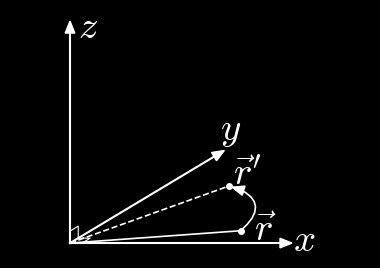

In [97]:

n_x = np.array([1,0])
n_z = np.array([0,1])
n_y = np.array([1,0.6])
n_y = n_y/np.linalg.norm(n_y)*0.8

#Theme.set("light")
Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}
fig = plt.figure(figsize=(1.5*2.4,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 1.5*0.4)
ax.set_ylim(0, 0.4)

center = np.array([0.1,0.02])
ax.add_line(mpl.lines.Line2D([center[0], center[0] + n_x[0]*0.36],
                             [center[1], center[1] + n_x[1]*0.36], linewidth=1.5,color= main_color))
ax.add_line(mpl.lines.Line2D([center[0], center[0] + n_z[0]*0.36], 
                             [center[1], center[1] + n_z[1]*0.36], linewidth=1.5,color= main_color))
ax.add_line(mpl.lines.Line2D([center[0], center[0] + n_y[0]*0.36], 
                             [center[1], center[1] + n_y[1]*0.36], linewidth=1.5,color= main_color))

def add_corner(x0, dx1, dx2):
    ax.add_line(mpl.lines.Line2D([x0[0], x0[0] + dx1[0], x0[0] + dx1[0] + dx2[0]], 
                                 [x0[1], x0[1] + dx1[1], x0[1] + dx1[1] + dx2[1]], 
                                 linewidth=0.8,color= main_color))
add_corner(center + n_z*0.02,n_y*0.02,-n_z*0.02)
add_corner(center + n_x*0.02,n_y*0.02,-n_x*0.02)


from matplotlib.patches import Polygon

arrow = Polygon(make_arrow(*(center + n_z*0.35),*n_z,0.016,0.02),color= main_color)
ax.add_patch(arrow)

arrow = Polygon(make_arrow(*(center + n_x*0.35),*n_x,0.016,0.02),color= main_color)
ax.add_patch(arrow)

arrow = Polygon(make_arrow(*(center + n_y*0.35),*n_y,0.016,0.02),color= main_color)
ax.add_patch(arrow)

diagram.text(*(center + n_z*0.36 + [0.03,0]), r"$z$", fontsize=28)
diagram.text(*(center + n_x*0.36 + [0.03,0.005]), r"$x$", fontsize=28)
diagram.text(*(center + n_y*0.36 + [0.02,0.04]), r"$y$", fontsize=28)


(x0,y0) =  (0.25, 0.05)
X0 = center + n_x * x0 + n_y * y0
ax.add_line(mpl.lines.Line2D([center[0], X0[0]],
                             [center[1], X0[1]], linewidth=1.2,color= main_color))
diagram.vertex(X0,**style_params,markersize=4)

diagram.text(*(X0 + [0.04,0.0]), r"$\vec{r}$", fontsize=28)

Theta = np.pi*0.3

(x1,y1) = (np.cos(Theta)*x0 - np.sin(Theta)*y0, np.sin(Theta)*x0 + np.cos(Theta)*y0)
X1 = center + n_x * x1 + n_y * y1
ax.add_line(mpl.lines.Line2D([center[0], X1[0]],
                             [center[1], X1[1]], linewidth=1.2,linestyle = '--',color= main_color))
diagram.vertex(X1,**style_params,markersize=4)

diagram.text(*(X1 + [0.03,0.02]), r"$\vec{r}'$", fontsize=28)

thetas = np.linspace(0,Theta,10)

M_Line = np.array([center[i] + n_x[i] * (np.cos(thetas)*x0 - np.sin(thetas)*y0) + n_y[i] * (np.sin(thetas)*x0 + np.cos(thetas)*y0) for i in range(2)])

ax.add_line(mpl.lines.Line2D(M_Line[0,:], M_Line[1,:], linewidth=1.2,color= main_color))


arrow = Polygon(make_arrow(*(X1 + [0.024,-0.008]), 
                            -1,0.3,
                            0.016, 0.02), color= main_color)
ax.add_patch(arrow)

diagram.plot()

fig.savefig(f'../docs/Neutrino/images/RightCoordinate-{Theme.suff()}.svg',transparent=True)

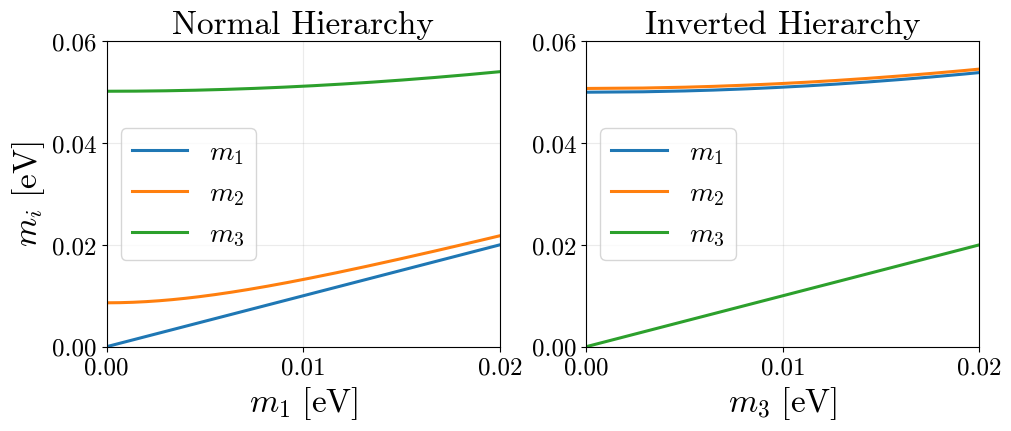

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# Если Theme уже определён выше в ноутбуке:
Theme.set("light")
#Theme.set("dark")

main_color = Theme.color()

# Экспериментальные значения, эВ^2
dm21 = 7.42e-5
dm31_NO = 2.517e-3      # normal ordering: m3^2 - m1^2
dm31_abs_IO = 2.498e-3  # inverted ordering: |m3^2 - m1^2|

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), constrained_layout=True)

# ------------------------
# Левая панель: прямая иерархия
# ------------------------
m1_no = np.linspace(0.0, 0.10, 600)
m2_no = np.sqrt(m1_no**2 + dm21)
m3_no = np.sqrt(m1_no**2 + dm31_NO)

ax = axes[0]
ax.plot(m1_no, m1_no, lw=2.2, label=r"$m_1$")
ax.plot(m1_no, m2_no, lw=2.2, label=r"$m_2$")
ax.plot(m1_no, m3_no, lw=2.2, label=r"$m_3$")
ax.set_xlim(0, 0.02)
ax.set_ylim(0, 0.06)

ax.set_title("Normal Hierarchy", color=main_color, fontsize=24)
ax.set_xlabel(r"$m_1\ \mathrm{[eV]}$", color=main_color, fontsize=24)
ax.set_ylabel(r"$m_i\ \mathrm{[eV]}$", color=main_color, fontsize=24)
ax.grid(alpha=0.25)
ax.legend(frameon=True, fontsize=20)

# ------------------------
# Правая панель: обратная иерархия
# Здесь m1 не может быть слишком малым, иначе m3 станет мнимой:
# m3^2 = m1^2 - |Δm31^2| >= 0
# ------------------------
m1_min_io = np.sqrt(dm31_abs_IO) 
m1_io = np.linspace(m1_min_io, 0.10, 600)

m2_io = np.sqrt(m1_io**2 + dm21)
m3_io = np.sqrt(m1_io**2 - dm31_abs_IO)

ax = axes[1]
ax.plot(m3_io, m1_io, lw=2.2, label=r"$m_1$")
ax.plot(m3_io, m2_io, lw=2.2, label=r"$m_2$")
ax.plot(m3_io, m3_io, lw=2.2, label=r"$m_3$")
ax.set_xlim(0, 0.02)
ax.set_ylim(0, 0.06)

ax.set_title("Inverted Hierarchy", color=main_color, fontsize=24)
ax.set_xlabel(r"$m_3\ \mathrm{[eV]}$", color=main_color, fontsize=24)
#ax.set_ylabel(r"$m_i\ \mathrm{[eV]}$", color=main_color, fontsize=24)
ax.grid(alpha=0.25)
ax.legend(frameon=True, fontsize=20)

for ax in axes:
    ax.tick_params(axis="x", colors=main_color, labelsize=18)
    ax.tick_params(axis="y", colors=main_color, labelsize=18)
    ax.set_xticks([0.00, 0.01, 0.02])
    ax.set_yticks([0.00, 0.02, 0.04, 0.06])
plt.show()
fig.savefig(f'../docs/Neutrino/images/MassHierarchy-{Theme.suff()}.svg',transparent=True)

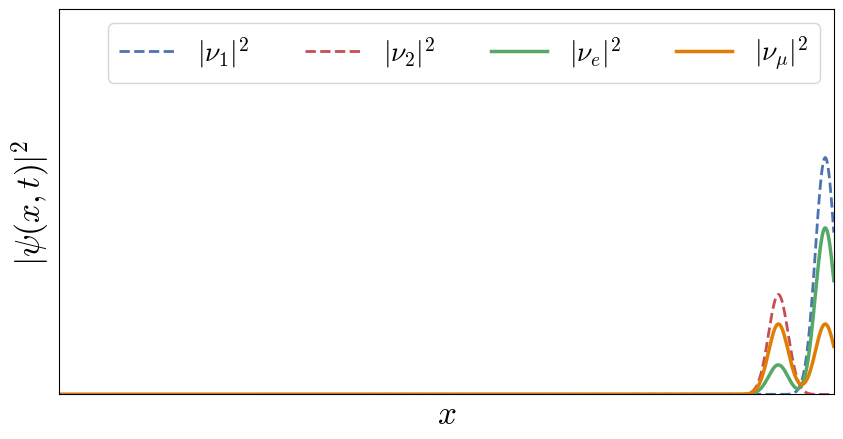

In [352]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io
import os

Theme.set("light")
#Theme.set("dark")


# Параметры модели (натуральные единицы: c = ħ = 1)
theta = np.deg2rad(33.0)   # угол смешивания
m1, m2 = 0.30, 0.80        # массы
p0 = 2.0                   # средний импульс
sigma = 3.8                # ширина гауссова пакета
x0 = 0                # начальная позиция центра пакета

# Пространственная сетка
x = np.linspace(0, 300, 1600)
dx = x[1] - x[0]

# Энергии и групповые скорости
E1 = np.sqrt(p0**2 + m1**2)
E2 = np.sqrt(p0**2 + m2**2)
v1 = p0 / E1
v2 = p0 / E2

# Нормировка гауссова пакета
A = (1.0 / (2.0 * np.pi * sigma**2))**0.25

def packet(x, t, v, E):
    env = np.exp(-((x - (x0 + v * t))**2) / (4.0 * sigma**2))
    phase = np.exp(1j * (p0 * x - E * t))
    return A * env * phase

def states_at_t(t):
    # Массовые состояния для начального flavor-состояния nu_e:
    # |nu_e> = cos(theta)|nu_1> + sin(theta)|nu_2>
    psi1 = np.cos(theta) * packet(x, t, v1, E1)
    psi2 = np.sin(theta) * packet(x, t, v2, E2)

    # Flavor-состояния через обратное преобразование
    psi_e  =  np.cos(theta) * psi1 + np.sin(theta) * psi2
    psi_mu = -np.sin(theta) * psi1 + np.cos(theta) * psi2

    return np.abs(psi1)**2, np.abs(psi2)**2, np.abs(psi_e)**2, np.abs(psi_mu)**2

# Временная сетка анимации
times = np.linspace(0, 300, 260)

# Фигура
fig, ax = plt.subplots(figsize=(10, 5))

if(Theme.suff()== "d"):
    fig.patch.set_facecolor("#1E2129")
    ax.set_facecolor("#1E2129")

ax.set_xlim(x.min(), x.max())
ax.set_ylim(0, 0.12)
ax.set_xlabel("$x$",fontsize = 24)
ax.set_ylabel(r"$|\psi(x,t)|^2$", fontsize=24)

ax.set_xticks([])
ax.set_yticks([])

# Линии: массовые (пунктир), флейворные (сплошные)
line_m1, = ax.plot([], [], "--", lw=2, color="#4C72B0", label=r"$|\nu_1|^2$")
line_m2, = ax.plot([], [], "--", lw=2, color="#C44E52", label=r"$|\nu_2|^2$")
line_e,  = ax.plot([], [], "-",  lw=2.5, color="#55A868", label=r"$|\nu_e|^2$")
line_mu, = ax.plot([], [], "-",  lw=2.5, color="#E17C05", label=r"$|\nu_\mu|^2$")
ax.legend(loc="upper right",frameon=True, fontsize=20, ncol=4)

info = ax.text(0.02, 0.92, "", transform=ax.transAxes)

def init():
    line_m1.set_data([], [])
    line_m2.set_data([], [])
    line_e.set_data([], [])
    line_mu.set_data([], [])
    info.set_text("")
    return line_m1, line_m2, line_e, line_mu, info

def update(i):
    t = times[i]
    m1_d, m2_d, e_d, mu_d = states_at_t(t)

    line_m1.set_data(x, m1_d)
    line_m2.set_data(x, m2_d)
    line_e.set_data(x, e_d)
    line_mu.set_data(x, mu_d)

    P_e = np.trapezoid(e_d, x)
    P_mu = np.trapezoid(mu_d, x)
    return line_m1, line_m2, line_e, line_mu, info

ani = FuncAnimation(fig, update, frames=len(times), init_func=init, interval=50, blit=True)

# Для отображения в Jupyter

ani.save(
    f"../docs/Neutrino/images/neutrino-oscillation-{Theme.suff()}.gif",
    writer=PillowWriter(fps=20),
    dpi=150,
)



plt.show()

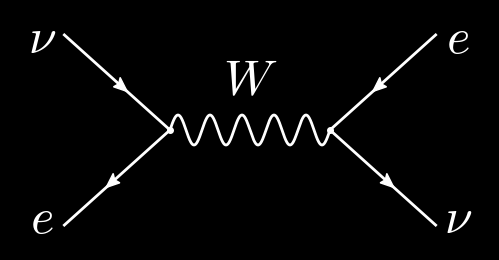

In [16]:
#Theme.set("light")
Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center1 = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
center2 = diagram.vertex(xy=(0.6, 0.2), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.8, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.8, H-0.04), marker='', **style_params)

diagram.line(center1,in1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1, center2, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line( out2,center2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]+0.08, r"$W$", fontsize=36)
diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$\nu$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$e$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$e$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$\nu$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/Neutrino/images/nueCC-{Theme.suff()}.svg',transparent=True)

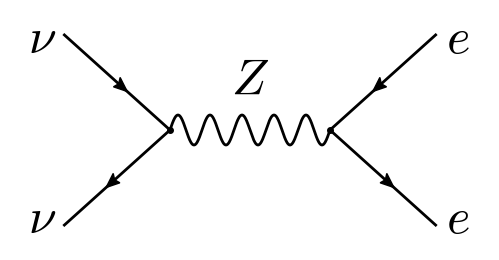

In [21]:
Theme.set("light")
#Theme.set("dark")
main_color = Theme.color()
style_params = {"color": main_color}
arrow_params = {"color": main_color,"width":0.02,"length":0.05}
fig = plt.figure(figsize=(4.8,2.4))
ax = fig.add_axes([0,0,1,1 ], frameon=False)
diagram = Diagram(ax)

ax.set_xlim(0, 0.9)
ax.set_ylim(0, 0.4)

H = 0.4
in1 = diagram.vertex(xy=(0.1, 0.04), marker='', **style_params)
in2 = diagram.vertex(xy=(0.1, H-0.04), marker='', **style_params)
center1 = diagram.vertex(xy=(0.3, 0.2), **style_params,markersize=4)
center2 = diagram.vertex(xy=(0.6, 0.2), **style_params,markersize=4)
out1 = diagram.vertex(xy=(0.8, 0.04), marker='', **style_params)
out2 = diagram.vertex(xy=(0.8, H-0.04), marker='', **style_params)

diagram.line(center1,in1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(in2,center1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line(center1, center2, **style_params,style='wiggly',linewidth=2,arrow_param=arrow_params)
diagram.line(center2, out1, **style_params,linewidth=2,arrow_param=arrow_params)
diagram.line( out2,center2, **style_params,linewidth=2,arrow_param=arrow_params)

diagram.text((center1.xy[0]+center2.xy[0])/2, center1.xy[1]+0.08, r"$Z$", fontsize=36)
diagram.text(out1.xy[0]+0.04, out1.xy[1]+0.01, r"$e$", fontsize=36)
diagram.text(out2.xy[0]+0.04, out2.xy[1]-0.01, r"$e$", fontsize=36)
diagram.text(in1.xy[0]-0.04, out1.xy[1]+0.01, r"$\nu$", fontsize=36)
diagram.text(in2.xy[0]-0.04, out2.xy[1]-0.01, r"$\nu$", fontsize=36)


diagram.plot()
fig.savefig(f'../docs/Neutrino/images/nueNC-{Theme.suff()}.svg',transparent=True)

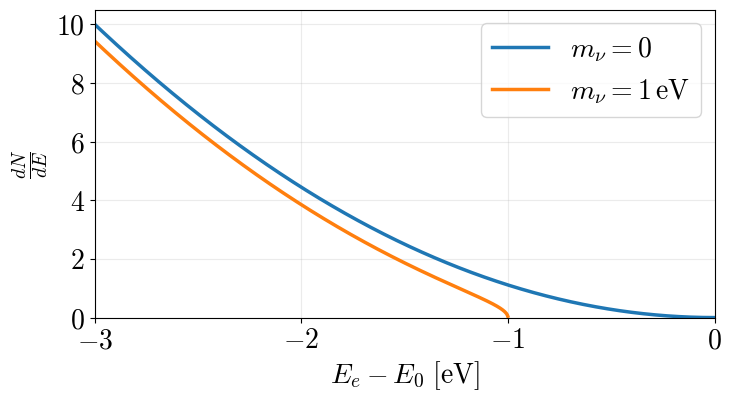

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Если Theme уже определен выше:
Theme.set("light")
#Theme.set("dark")

main_color = Theme.color()

# Конечная энергия электрона в бета-распаде трития
# Здесь берем характерный endpoint по кинетической энергии
E0 = 18_600.0  # eV

# Смотрим только последние 5 eV перед endpoint
delta = np.linspace(0.0, 3.0, 1200)   # delta = E0 - E
E = E0 - delta

# Для наглядности возьмем пример ненулевой массы
mnu0 = 0.0
mnu1 = 1.0   # eV

def beta_tail(delta, mnu):
    X = delta[delta >= mnu]
    y = np.zeros_like(X)
    y = X * np.sqrt(X**2 - mnu**2)
    return (-X,y)

X0,S0 = beta_tail(delta, mnu0)
X1,S1 = beta_tail(delta, mnu1)

# Нормируем на максимум безмассового случая для удобного сравнения
Norm = S0.max()
S0 /= Norm
S1 /= Norm

fig, ax = plt.subplots(figsize=(8., 4.0))
ax.plot(X0, S0, lw=2.5, label=r"$m_\nu = 0$")
ax.plot(X1, S1, lw=2.5, label=r"$m_\nu = 1\,\text{eV}$")

ax.set_xlim(-3, 0)
ax.set_ylim(0, 1.05)

ax.set_xlabel(r"$E_e - E_0\ \text{[eV]}$", color=main_color, fontsize=20)

ax.set_ylabel(r"$\frac{dN}{dE}$", color=main_color, fontsize=20)
ax.grid(alpha=0.25)
ax.legend(frameon=True, fontsize=20)

ax.tick_params(axis="x", colors=main_color, labelsize=20)
ax.set_yticks([0,0.2,0.4,0.6,0.8,1])
ax.set_yticklabels([f'${y}$' for y in range(0,12,2)], fontsize=20)
ax.set_xticks([-3, -2, -1, 0])
ax.set_xticklabels([f'${x}$' for x in [ -3, -2, -1, 0]], fontsize=20)

plt.show()
fig.savefig(f"../docs/Neutrino/images/tritium-endpoint-{Theme.suff()}.svg", transparent=True,
            bbox_inches='tight')

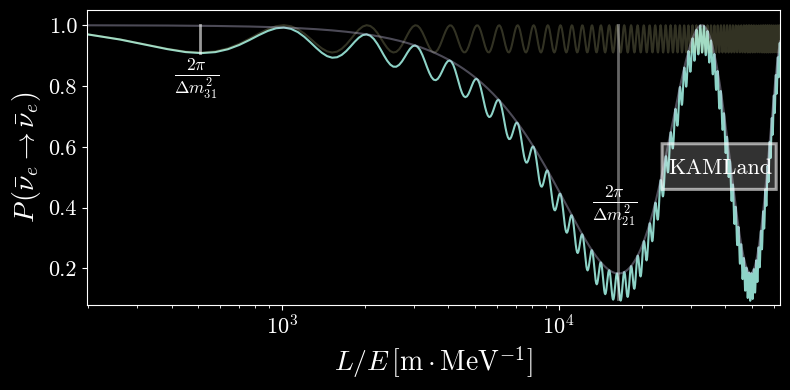

In [281]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, LogLocator, NullFormatter
from pathlib import Path
from matplotlib.collections import LineCollection
from matplotlib.patches import FancyBboxPatch


    

#Theme.set("light")
Theme.set("dark")
#
main_color = Theme.color()

fig, ax = plt.subplots(figsize=(8., 4.0))

dm12 = 7.53e-5  # eV^2, примерное значение для Δm^2_21
dm13 = 2.44e-3  # eV^2, примерное значение для Δm^2_31

s13_sq = 0.023
s23_sq = 0.55
s12_sq = 0.31

def sin2theta_sq(s_sq):
    return 4 * s_sq * (1 - s_sq)

X = np.linspace(0.1e4, 32*1e4, 1000)/5.067
Y1 = 1 - sin2theta_sq(s13_sq)*np.sin(dm13*X/4*5.067)**2 - (1 - s13_sq)**2*sin2theta_sq(s12_sq)*np.sin(dm12*X/4*5.067)**2
Y2 = 1 - sin2theta_sq(s13_sq)*np.sin(dm13*X/4*5.067)**2 
Y3 = 1  - (1 - s13_sq)**2*sin2theta_sq(s12_sq)*np.sin(dm12*X/4*5.067)**2
    
ax.plot(X, Y1, label='Y1')
ax.plot(X, Y2, label='Y2',alpha=0.2)
ax.plot(X, Y3, label='Y3',alpha=0.4)

X13 = 2*np.pi/dm13/5.067
X12 = 2*np.pi/dm12/5.067

ax.plot([X13,X13],[1 - 4*s13_sq,1],lw = 2, color=(main_color,0.6))
ax.plot([X12,X12],[0.1,1],lw = 2, color=(main_color,0.4))

ax.text(X13*0.8, 0.82, r'$\frac{2\pi}{\Delta m^2_{31}}$', fontsize=18, color=main_color)
ax.text(X12*0.8, 0.4, r'$\frac{2\pi}{\Delta m^2_{21}}$', fontsize=18, color=main_color)


box = FancyBboxPatch(
    (1.2e5/5.067, 0.46),
    1.9e5/5.067,0.15,
    boxstyle="round,pad=0,rounding_size=0",
    linewidth=2.2,
    edgecolor=(main_color,0.6),
    facecolor=(main_color,0.2),
    zorder=4,
)
ax.add_patch(box)
ax.text(
    1.95e5/5.067,0.53,r'KAMLand',ha="center",va="center",
    fontsize=16,color=main_color,zorder=11,
)


ax.set_xlim(X[0], X[-1])
ax.set_ylim(0.08, 1.05)
ax.set_xticks([1e3,1e4])
ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax.set_xticklabels(ax.get_xticklabels(), fontsize = 16)
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 16)

ax.set_xscale('log')
ax.set_xlabel(r'$L/E \,[\text{m}\cdot\text{MeV}^{-1}]$', fontsize=20)
ax.set_ylabel(r'$P\,(\bar{\nu}_e \to \bar{\nu}_e)$', fontsize=20)

fig.tight_layout()
output = Path("../docs/Neutrino/images") / f"OscillationPlot-{Theme.suff()}.svg"
fig.savefig(output, transparent=True, bbox_inches="tight")

plt.show()


In [283]:
1/8 * (1 - s12_sq)**0.5*(sin2theta_sq(s12_sq)*sin2theta_sq(s13_sq)*sin2theta_sq(s23_sq))**0.5

0.02865027132240635

In [285]:
X,Y = np.meshgrid(np.linspace(-5,5,1000), np.linspace(-5,5,1000))

print(float(np.max(np.sin(X)*np.sin(Y)*np.sin(X+Y))), " vs ", 3**1.5/8)

0.6495186391908866  vs  0.649519052838329


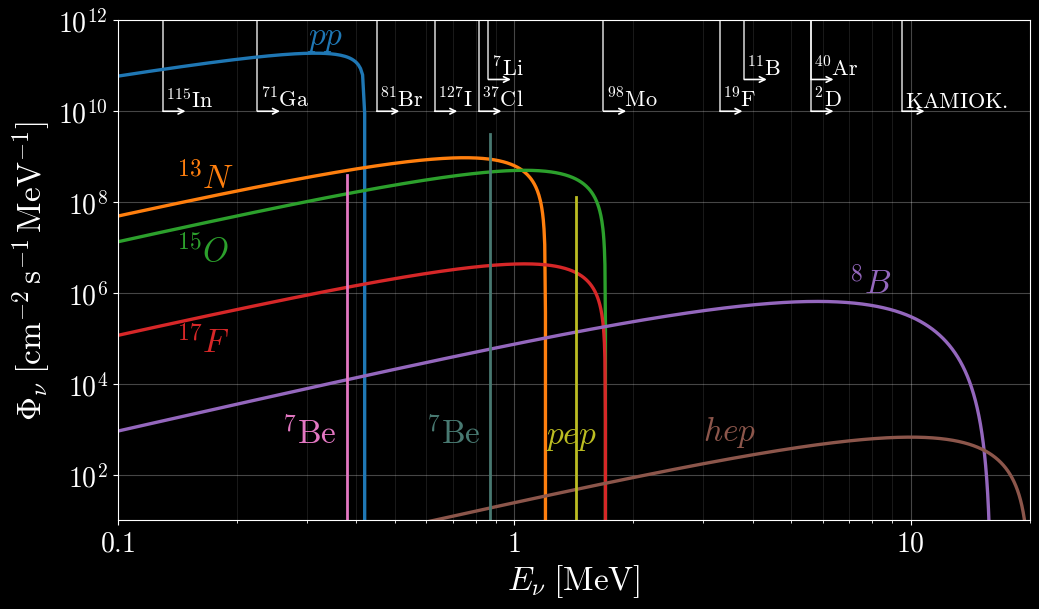

In [242]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, LogLocator, NullFormatter
from pathlib import Path

background_image = plt.imread("SpectNSolar.png")

solar_fluxes = {
    "$pp$": 4.8e10,
    "$^{13}N$": 6.4e8,
    "$^{15}O$": 4.8e8,
    "$^{17}F$": 4.2e6,
    "$^{8}B$": 4.8e6,
    "$hep$": 7.25e3,
    "$pep$": 1.3e8,
    "$^7$Be_384": 4.0e8,
    "$^7$Be_862": 3.2e9,
}

continuum_sources = [
    ("$pp$", 0.42, 1.5, 0.5, "#1f77b4", {"X": 0.30, "Y": 3.0e11}),
    ("$^{13}N$", 1.2, 2.0, 1.2, "#ff7f0e", {"X": 0.14, "Y": 2.0e8}),
    ("$^{15}O$", 1.7, 2.0, 1.2, "#2ca02c", {"X": 0.14, "Y": 0.5e7}),
    ("$^{17}F$", 1.7, 2.0, 1.2, "#d62728", {"X": 0.14, "Y": 0.5e5}),
    ("$^{8}B$", 16.0, 2.0, 3.5, "#9467bd", {"X": 7.0, "Y": 1.0e6}),
    ("$hep$", 20.0, 2.0, 2.0, "#8c564b", {"X": 3.0, "Y": 0.6e3}),
]

line_sources = [
    (r"$^7$Be", 0.38, solar_fluxes["$^7$Be_384"], "#e377c2", {"X": 0.26, "Y": 0.5e3}),
    (r"$^7$Be", 0.87, solar_fluxes["$^7$Be_862"], "#487971", {"X": 0.6, "Y": 0.5e3}),
    ("$pep$", 1.43, solar_fluxes["$pep$"], "#bcbd22", {"X": 1.20, "Y": 0.5e3}),
]

detector_thresholds = [
    {"label": r"$^{115}\mathrm{In}$", "energy": 0.13, "text_y": 1.45e11, "arrow_y": 1.00e10},
    {"label": r"$^{71}\mathrm{Ga}$", "energy": 0.225, "text_y": 1.45e11, "arrow_y": 1.00e10},
    {"label": r"$^{81}\mathrm{Br}$", "energy": 0.45, "text_y": 1.45e11, "arrow_y": 1.00e10},
    {"label": r"$^{127}\mathrm{I}$", "energy": 0.63, "text_y": 1.45e11, "arrow_y": 1.00e10},
    {"label": r"$^{7}\mathrm{Li}$", "energy": 0.86, "text_y": 3.60e11, "arrow_y": 5e10},
    {"label": r"$^{37}\mathrm{Cl}$", "energy": 0.814, "text_y": 1.10e11, "arrow_y": 1.00e10},
    {"label": r"$^{98}\mathrm{Mo}$", "energy": 1.68, "text_y": 1.45e11, "arrow_y": 1.00e10},
    {"label": r"$^{19}\mathrm{F}$", "energy": 3.3, "text_y": 1.45e11, "arrow_y": 1.00e10},
    {"label": r"$^{11}\mathrm{B}$", "energy": 3.8, "text_y": 3.60e11, "arrow_y": 5e10},
    {"label": r"$^{2}\mathrm{D}$", "energy": 5.6, "text_y": 1.45e11, "arrow_y": 1.00e10},
    {"label": r"$^{40}\mathrm{Ar}$", "energy": 5.6, "text_y": 2.30e11, "arrow_y": 5.00e10},
    {"label": r"$\mathrm{KAMIOK.}$", "energy": 9.5, "text_y": 1.20e11, "arrow_y": 1.00e10},
]

energy = np.linspace(0.01, 20.0, 4000)

def continuum_spectrum(energy_grid, endpoint, total_flux, alpha, beta):
    spectrum = np.zeros_like(energy_grid)
    mask = energy_grid < endpoint
    x = energy_grid[mask] / endpoint
    shape = np.power(np.clip(x, 0.0, None), alpha) * np.power(np.clip(1.0 - x, 0.0, None), beta)
    norm = np.trapezoid(shape, energy_grid[mask])
    if norm > 0:
        spectrum[mask] = total_flux * shape / norm
    return spectrum

def line_spectrum(line_energy, total_flux):
    X = [line_energy, line_energy]
    Y = [0, total_flux]
    return [X, Y]

def style_axes(ax, main_color):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(0.1, 20.0)
    ax.set_ylim(10, 1.0e12)
    ax.set_xlabel(r"$E_\nu\;[\mathrm{MeV}]$", color=main_color, fontsize=24)
    ax.set_ylabel(r"$\Phi_\nu\;[\mathrm{cm}^{-2}\,\mathrm{s}^{-1}\,\mathrm{MeV}^{-1}]$", color=main_color, fontsize=24)

    y_ticks = [1e2, 1e4, 1e6, 1e8, 1e10, 1e12]
    x_ticks = [0.1, 1, 10]

    ax.yaxis.set_major_locator(FixedLocator(y_ticks))
    ax.xaxis.set_major_locator(FixedLocator(x_ticks))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.xaxis.set_minor_formatter(NullFormatter())

    ax.set_yticklabels([f"$10^{{{y}}}$" for y in [2, 4, 6, 8, 10, 12]], fontsize=20, color=main_color)
    ax.set_xticklabels(["$0.1$", "$1$", "$10$"], fontsize=20, color=main_color)
    ax.tick_params(axis="both", which="minor", colors=main_color)

    ax.grid(which="major", alpha=0.28)
    ax.grid(which="minor", alpha=0.10)

def add_background(ax):
    ax.imshow(
        background_image,
        extent=(0.0, 1.0, 0.0, 1.0),
        transform=ax.transAxes,
        aspect="auto",
        alpha=0.32,
        zorder=0,
        interpolation="bilinear"
    )
    ax.patch.set_alpha(0.0)

def add_detector_thresholds(ax, main_color):
    for detector in detector_thresholds:
        energy_threshold = detector["energy"]
        text_y = detector["text_y"]
        arrow_y = detector["arrow_y"]
        arrow_end = min(energy_threshold * 1.16, 19.5)

        ax.vlines(
            energy_threshold,
            arrow_y,
            1.0e12,
            colors=main_color,
            linewidth=1.1,
            alpha=0.85,
            zorder=1.5
        )
        ax.annotate(
            "",
            xy=(arrow_end, arrow_y),
            xytext=(energy_threshold*0.985, arrow_y),
            arrowprops=dict(arrowstyle="->", color=main_color, lw=1.2),
            zorder=3
        )
        ax.text(
            energy_threshold * 1.02,
            arrow_y * 1.02,
            detector["label"],
            color=main_color,
            fontsize=16,
            ha="left",
            va="bottom",
            zorder=3
        )

def draw_solar_spectra(theme_name, show=False):
    Theme.set(theme_name)
    main_color = Theme.color()
    fig, ax = plt.subplots(figsize=(10.5, 6.2))

    style_axes(ax, main_color)
    #add_background(ax)
    add_detector_thresholds(ax, main_color)

    for name, endpoint, alpha, beta, color, legend_info in continuum_sources:
        spectrum = continuum_spectrum(energy, endpoint, solar_fluxes[name], alpha, beta)
        ax.plot(energy, spectrum, lw=2.4, color=color, label=name, zorder=2)
        ax.text(legend_info["X"], legend_info["Y"], name, color=color, fontsize=24, zorder=3)

    for label, line_energy, total_flux, color, legend_info in line_sources:
        [X, Y] = line_spectrum(line_energy, total_flux)
        ax.plot(X, Y, lw=2.0, color=color, label=label, zorder=2)
        ax.text(legend_info["X"], legend_info["Y"], label, color=color, fontsize=24, zorder=3)

    fig.tight_layout()
    output = Path("../docs/Neutrino/images") / f"solar-neutrino-spectra-{Theme.suff()}.svg"
    fig.savefig(output, transparent=True, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)

draw_solar_spectra("dark", show=True)
#draw_solar_spectra("light", show=True)

In [135]:
np.log(20/0.1)/np.log(10/0.1)

np.float64(1.1505149978319904)

## PP cycle

In [132]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Polygon
from matplotlib.lines import Line2D
from pathlib import Path




# ============================================================
# DRAW NUCLEUS
# ============================================================

def draw_node(label, xy,edgecolor = "white",facecolor = "black",node_w = 0.5,node_h = 0.4):
    x, y = xy

    box = FancyBboxPatch(
        (x - node_w / 2, y - node_h / 2),
        node_w,
        node_h,
        boxstyle="round,pad=0.06,rounding_size=0.08",
        linewidth=2.2,
        edgecolor=edgecolor,
        facecolor=facecolor,
        zorder=4,
    )
    ax.add_patch(box)
    ax.text(
        x,y,label,ha="center",va="center",
        fontsize=24,color=c_text,zorder=11,
    )


def point(name, side):
    x, y = pos[name]
    return np.array( {
        "left":   (x - node_w / 2, y),
        "right":  (x + node_w / 2, y),
        "top":    (x, y + node_h / 2),
        "bottom": (x, y - node_h / 2),
        "center": (x, y),
    }[side])


# ============================================================
# ARROW
# ============================================================

def arrow(point_path,
    color,
    lw=2.0,
    ls="-",
    rad=0,
    mutation=15,
    h = 0.1,l = 0.16
):
    XY = np.array(point_path)
    X = XY[:, 0]
    Y = XY[:, 1]
    L = Line2D(X,Y,color=color,linewidth = lw,linestyle=ls,zorder = 3)
    ax.add_line(L)
    arrow = make_arrow(X[-1],Y[-1],X[-1]-X[-2],Y[-1]-Y[-2],h = h,l=l,position='start')
    ax.add_patch(Polygon(arrow, color=color,zorder = 3))


# ============================================================
# REACTION LABEL
#
# reaction — top line
# info     — bottom line
# ============================================================

def reaction_text(x,y,reaction,color,fontsize=20,bckg_color = None,brdcolor =None,rotation = "horizontal"):
    # Reaction
    ax.text(
        x,y,reaction,
        ha="center", va="center", rotation=rotation,
        fontsize=fontsize,color=color,zorder=11,
        bbox=dict(
           boxstyle="round,pad=0.18",
           facecolor=(bckg_color if bckg_color is not None else color,0.2),
           edgecolor=(brdcolor if brdcolor is not None else color,0.5),
           zorder=8
        ),
    )



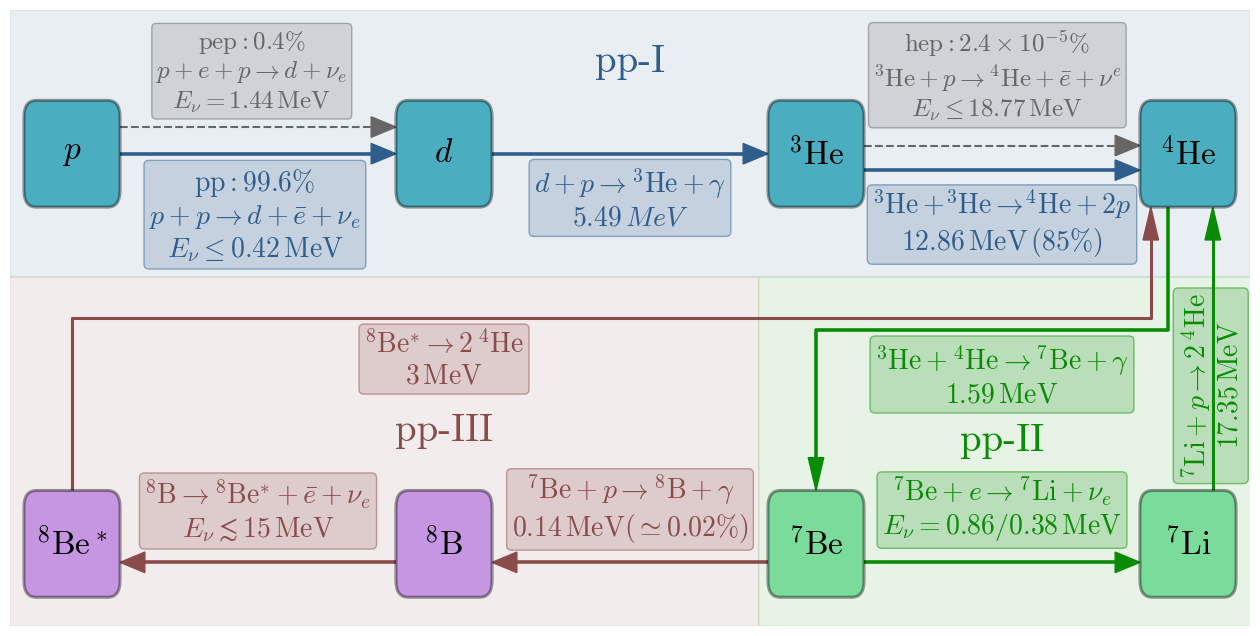

In [290]:
Theme.set("light")
#Theme.set("dark")

c_text =Theme.color()
c_edge = Theme.color()

if Theme.suff() == 'l':
    c_pp1 = "#2F5D8C"   # pp-I
    c_pp2 = "#0A8B05"   # pp-II
    c_pp3 = "#8A4B4B"   # pp-III
    c_rare = "#666666"  # pep / hep

    c_pp1_els = "#4BAEC0"   # pp-I
    c_pp2_els = "#7BDB9B"   # pp-II
    c_pp3_els = "#C696E2"   # pp-III
else:
    c_pp1 = "#5CC7CA"   # pp-I
    c_pp2 = "#40E648"   # pp-II
    c_pp3 = "#ECCDB4"   # pp-III
    c_rare = "#CCCCCC"  # pep / hep

    c_pp1_els = "#295B64"   # pp-I
    c_pp2_els = "#253F2E"   # pp-II
    c_pp3_els = "#3B2C44"   # pp-III

fig, ax = plt.subplots(figsize=(16, 8),frameon=False)

ax.set_xlim(0, 8.0)
ax.set_ylim(0, 3.0)
ax.axis("off")

pos = {
    "p":   (0.4, 2.3),
    "d": (2.8, 2.3),
    "3He": (5.2, 2.3),
    "4He": (7.6, 2.3),

    "8Be":   (0.4, 0.4),
    "8B": (2.8, 0.4),
    "7Be":  (5.2, 0.4),
    "7Li": (7.6, 0.4),
}


# Draw all nuclei
for key, label,color in [
    ("p",   r"$p$",c_pp1_els ),
    ("3He", r"$^3\mathrm{He}$",c_pp1_els),
    ("7Be", r"$^7\mathrm{Be}$",c_pp2_els),
    ("7Li", r"$^7\mathrm{Li}$",c_pp2_els),

    ("d",   r"$d$",c_pp1_els),
    ("4He", r"$^4\mathrm{He}$",c_pp1_els),
    ("8B",  r"$^8\mathrm{B}$",c_pp3_els),
    ("8Be", r"$^8\mathrm{Be}^*$",c_pp3_els),
]:
    draw_node(label, pos[key],edgecolor=(c_edge,0.4),facecolor=color)



# ============================================================
# PP-I
# ============================================================

# ------------------------------------------------------------
# p -> d
# ------------------------------------------------------------

arrow([point("p", "right") + (0.06,-0.0),point("d", "left")+ (-0.22,-0.0)],color=c_pp1,lw=2.6,)
m_point_pp = (point("p", "right") + point("d", "left"))/2
reaction_text(m_point_pp[0]-0.02,m_point_pp[1]-0.3,
    "$\\mathrm{pp}: 99.6\\%$" + "\n" +
    r"$p+p\rightarrow d+\bar{e}+\nu_e$" + "\n" + r"$E_\nu\leq0.42\,\text{MeV}$",
    c_pp1,
)

# ------------------------------------------------------------
# d -> 3He
# ------------------------------------------------------------
arrow([point("d", "right")+ (0.06,0),point("3He", "left")+ (-0.22,0)],color=c_pp1,lw=2.6,)
m_point_dHe = (point("d", "right") + point("3He", "left"))/2
reaction_text(m_point_dHe[0],m_point_dHe[1]-0.22,
    r"$d+p\rightarrow{}^3\mathrm{He}+\gamma$" + "\n" +
    r"$5.49\,MeV$",c_pp1)
# ------------------------------------------------------------
# 3He -> 4He
# ------------------------------------------------------------
arrow([point("3He", "right") + (0.06,-0.08),point("4He", "left")+ (-0.22,-0.08)],color=c_pp1,lw=2.6,)
m_point_He34 = (point("3He", "right") + point("4He", "left"))/2 
reaction_text(m_point_He34[0],m_point_He34[1]-0.34,
    r"${}^3\mathrm{He}+ \! {}^3\mathrm{He}"
    r"\rightarrow \! {}^4\mathrm{He}+2p$" + "\n" +
    r"$12.86\,\text{MeV} \,(85\%)$",c_pp1,)
# ============================================================
# PP-II
# ============================================================
# ------------------------------------------------------------
# 3He -> 7Be
# ------------------------------------------------------------
dH = 0.66
arrow([point("4He", "bottom") + (-0.13,-0.06),point("4He", "bottom") + (-0.13,-dH),
    point("3He", "bottom")+ (0.,-dH),point("7Be", "top")+(0,0.22)],
    color=c_pp2,lw=2.6,)

m_HeBe = (point("3He", "bottom") + point("4He", "bottom") )/2
reaction_text(m_HeBe[0], m_HeBe[1] - dH-0.22,
    r"${}^3\mathrm{He}+{}^4\mathrm{He}"
    r"\rightarrow{}^7\mathrm{Be}+\gamma$" + "\n" +
    r"$1.59\,\text{MeV}$",c_pp2,)
# ------------------------------------------------------------
# 7Be -> 7Li
# ------------------------------------------------------------
arrow([point("7Be", "right") + (0.06,-0.09),point("7Li", "left") + (-0.22,-0.09)],color=c_pp2,lw=2.6,)
m_BeLi = (point("7Be", "left") + point("7Li", "right") )/2
reaction_text(m_BeLi[0], m_BeLi[1] + 0.17,
    r"${}^7\mathrm{Be}+e\rightarrow{}^7\mathrm{Li}+\nu_e$" + "\n" +
    r"$E_\nu=0.86/0.38\,\text{MeV}$",c_pp2,)

x_route = 8
y_route = 2.15

arrow([point("7Li", "top") + (0.16,0.06),point("4He", "bottom") + (0.16,-0.22)],color=c_pp2,lw=2.2,)
m_LiHe = (point("7Li", "top") + (0.16,0.06) + point("4He", "bottom") + (0.16,-0.22))/2
reaction_text(m_LiHe[0] - 0.01, m_LiHe[1] - 0.1,
    r"${}^7\mathrm{Li}+p\rightarrow2\,{}^4\mathrm{He}$" + "\n" +
    r"$17.35\,\text{MeV}$",c_pp2, rotation = "vertical"
)
# ============================================================
# PP-III
# ============================================================
# ------------------------------------------------------------
# 7Be -> 8B
# ------------------------------------------------------------
arrow([point("7Be", "left") + (-0.06,-0.09),point("8B", "right")+(0.22,-0.09)],color=c_pp3,lw=2.6,)
m_Be7B8 = (point("7Be", "right") + point("8B", "left"))/2
reaction_text(m_Be7B8[0], m_Be7B8[1]+0.17,
    r"${}^7\mathrm{Be}+p\rightarrow{}^8\mathrm{B}+\gamma$" + "\n" +
    r"$ 0.14\,\text{MeV} (\simeq0.02\%)$",c_pp3
)
# ------------------------------------------------------------
# 8B -> 8Be
# ------------------------------------------------------------
arrow([point("8B", "left") + (-0.06,-0.09),point("8Be", "right") + (0.22,-0.09)],color=c_pp3,lw=2.6,)
m_B8Be = (point("8B", "right") + point("8Be", "left"))/2
reaction_text(m_B8Be[0], m_B8Be[1]+0.16,
    r"${}^8\mathrm{B}\rightarrow{}^8\mathrm{Be}^{*}+\bar{e}+\nu_e$" + "\n" +
    r"$E_\nu\lesssim15\,\text{MeV}$",c_pp3)


Bdecay_dy = 0.9
arrow([point("8Be", "top"),point("8Be", "top") + (0,Bdecay_dy),
       (point("4He", "bottom")[0]-0.24, point("8Be", "top")[1] + Bdecay_dy),
       point("4He", "bottom")+(-0.24,-0.22)],
    color=c_pp3,lw=2.2)

m_BeHe = point("8Be", "top") + (1,Bdecay_dy-0.2)
reaction_text(m_BeHe[0]+1.4, m_BeHe[1],
    r"${}^8\mathrm{Be}^{*}\rightarrow2\,{}^4\mathrm{He}$" + "\n" +
    r"$3\,\text{MeV}$",c_pp3)

# ============================================================
# RARE pep AND hep REACTIONS
# ============================================================
# ------------------------------------------------------------
# pep: p -> d
# ------------------------------------------------------------

arrow([point("p", "right") + (0.06,+0.13),point("d", "left")+ (-0.22,+0.13)],
    color=c_rare, lw=1.5,ls="--",)

reaction_text(m_point_pp[0]-0.04,m_point_pp[1]+0.4,
    r"$\mathrm{pep}: 0.4\%$" + "\n" + r"$p+e+p\rightarrow d+\nu_e$" + "\n" +
    r"$E_\nu=1.44\,\text{MeV}$",
    c_rare,fontsize=18,
)
# ------------------------------------------------------------
# hep: 3He -> 4He
# ------------------------------------------------------------
arrow([point("3He", "right") + (0.06,0.04),point("4He", "left")+ (-0.22,0.04)],
    color=c_rare,lw=1.5,ls="--",
)
m_pointHe34_hep = (point("3He", "right") + point("4He", "left"))/2

reaction_text(m_pointHe34_hep[0]-0.03, m_pointHe34_hep[1]+ 0.38,
    r"$\mathrm{hep}: 2.4\times10^{-5}\%$" + "\n" +
    r"${}^3\mathrm{He}+p"
    r"\rightarrow{}^4\mathrm{He}+\bar{e}+\nu^e$" + "\n" +
    r"$E_\nu\leq18.77\,\text{MeV}$",
    fontsize=18,
    color=c_rare,
)


# ============================================================
# BRANCH LABELS
# ============================================================

ax.text(m_point_dHe[0],m_point_dHe[1]+0.4,"pp-I",
    fontsize=28,
    fontweight="bold",
    color=c_pp1,
    ha="center",
)

ax.text(m_BeLi[0],m_BeLi[1]+0.45,
    "pp-II",
    fontsize=28,
    fontweight="bold",
    color=c_pp2,
    ha="center",
)

ax.text( point("8B", "top")[0],0.9,
    "pp-III",
    fontsize=28,
    fontweight="bold",
    color=c_pp3,
    ha="center",
)

# put boxes to highlight groups

ax.add_patch(FancyBboxPatch(
    (0,1.7),8,1.3,zorder = 0,color = c_pp1,alpha = 0.1,linewidth = 1,boxstyle="round,pad=0.0,rounding_size=0.0")
)

ax.add_patch(FancyBboxPatch(
    (0, 0),4.83,1.7,zorder = 0,color = c_pp3,alpha = 0.1,linewidth = 1,boxstyle="round,pad=0.0,rounding_size=0.0")
)

ax.add_patch(FancyBboxPatch(
    (4.83, 0),3.27,1.7,zorder = 0,color = c_pp2,alpha = 0.1,linewidth = 1,boxstyle="round,pad=0.0,rounding_size=0.0")
)
# Show
output = Path("../docs/Neutrino/images") / f"pp-cycle-{Theme.suff()}.svg"
plt.savefig(output, transparent=True,bbox_inches="tight")
plt.show()

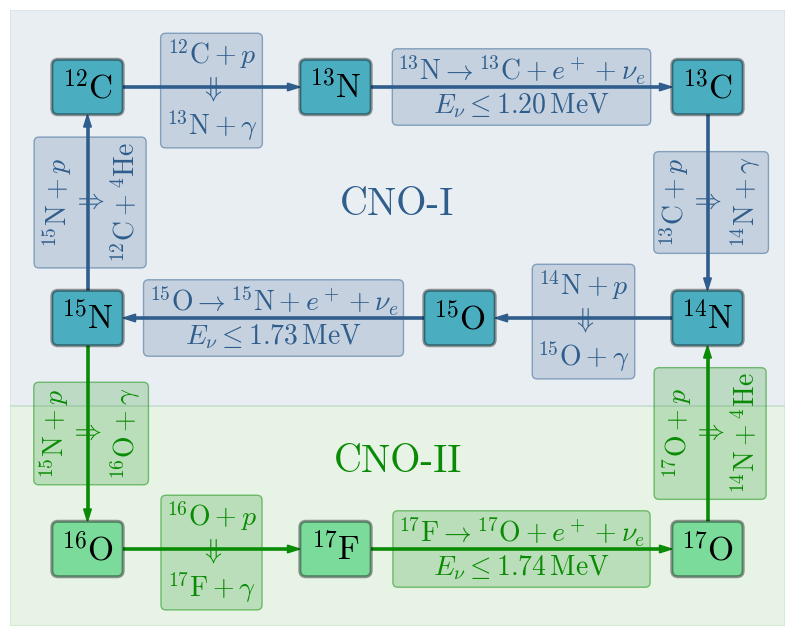

In [338]:
Theme.set("light")
#Theme.set("dark")

c_text = Theme.color()
c_edge = Theme.color()

if Theme.suff() == 'l':
    c_cno1 = "#2F5D8C"     # CNO-I
    c_cno2 =  "#0A8B05"     # CNO-II

    c_cno1_els = "#4BAEC0"
    c_cno2_els = "#7BDB9B"
else:
    c_cno1 = "#5CC7CA"      # CNO-I
    c_cno2 = "#40E648"      # CNO-II

    c_cno1_els = "#295B64"
    c_cno2_els = "#253F2E"


# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8), frameon=False)

W = 10
H = 8
ax.set_xlim(0, W)
ax.set_ylim(0, H)
ax.axis("off")


# ============================================================
# POSITIONS: 3 x 3 GRID
# ============================================================

X0,X1,X2 = 1, 5, 9.
Y0,Y1,Y2 = 1, 4, 7.

pos = {
    # top row
    "12C": (X0, Y2),
    "13N": (X1-0.8, Y2),
    "13C": (X2, Y2),

    # middle row
    "15N": (X0, Y1),
    "15O": (X1+0.8, Y1),
    "14N": (X2, Y1),

    # bottom row
    "16O": (X0, Y0),
    "17F": (X1-0.8, Y0),
    "17O": (X2, Y0),
}


# ============================================================
# DRAW NUCLEI
# ============================================================
node_w = 0.8
node_h = 0.6
for key, label, color in [

    # CNO-I
    ("12C", r"$^{12}\mathrm{C}$", c_cno1_els),
    ("13N", r"$^{13}\mathrm{N}$", c_cno1_els),
    ("13C", r"$^{13}\mathrm{C}$", c_cno1_els),
    ("14N", r"$^{14}\mathrm{N}$", c_cno1_els),
    ("15O", r"$^{15}\mathrm{O}$", c_cno1_els),
    ("15N", r"$^{15}\mathrm{N}$", c_cno1_els),

    # CNO-II
    ("16O", r"$^{16}\mathrm{O}$", c_cno2_els),
    ("17F", r"$^{17}\mathrm{F}$", c_cno2_els),
    ("17O", r"$^{17}\mathrm{O}$", c_cno2_els),
]:
    draw_node(
        label,
        pos[key],
        edgecolor=(c_edge, 0.4),
        facecolor=color,
        node_w=node_w,
        node_h=node_h
    )


# ============================================================
# CNO-I
# ============================================================


# ------------------------------------------------------------
# 12C + p -> 13N + gamma
# ------------------------------------------------------------

arrow([
    point("12C", "right") + (0.06, 0),
    point("13N", "left") + (-0.22, 0)
],
    color=c_cno1,
    lw=2.6,
)

m_C12_N13 = (
    point("12C", "right") +
    point("13N", "left")
) / 2

reaction_text(
    m_C12_N13[0],
    m_C12_N13[1] -0.04,
    r"$^{12}\mathrm{C}+p$" + "\n$\\Downarrow$\n" +
    r"${}^{13}\mathrm{N}+\gamma$",
    c_cno1,
)


# ------------------------------------------------------------
# 13N -> 13C + e+ + nu_e
# ------------------------------------------------------------

arrow([
    point("13N", "right") + (0.06, 0),
    point("13C", "left") + (-0.22, 0)
],
    color=c_cno1,
    lw=2.6,
)

m_N13_C13 = (
    point("13N", "right") +
    point("13C", "left")
) / 2

reaction_text(
    m_N13_C13[0],
    m_N13_C13[1],
    r"$^{13}\mathrm{N}"
    r"\rightarrow{}^{13}\mathrm{C}+e^++\nu_e$" + "\n" +
    r"$E_\nu\leq1.20\,\mathrm{MeV}$",
    c_cno1,
)


# ------------------------------------------------------------
# 13C + p -> 14N + gamma
# vertical: 13C -> 14N
# ------------------------------------------------------------

arrow([
    point("13C", "bottom") + (0, -0.06),
    point("14N", "top") + (0, 0.22)
],
    color=c_cno1,
    lw=2.6,
)

m_C13_N14 = (
    point("13C", "bottom") +
    point("14N", "top")
) / 2

reaction_text(
    m_C13_N14[0] + 0.04,
    m_C13_N14[1],
    r"$^{13}\mathrm{C}+p$" + "\n$\\Downarrow$\n"
    r"${}^{14}\mathrm{N}+\gamma$",
    c_cno1,
    rotation="vertical",
)


# ------------------------------------------------------------
# 14N + p -> 15O + gamma
# ------------------------------------------------------------

arrow([
    point("14N", "left") + (-0.06, 0),
    point("15O", "right") + (0.22, 0)
],
    color=c_cno1,
    lw=2.6,
)

m_N14_O15 = (
    point("14N", "left") +
    point("15O", "right")
) / 2

reaction_text(
    m_N14_O15[0],
    m_N14_O15[1] - 0.04,
    r"$^{14}\mathrm{N}+p$" +"\n$\\Downarrow$\n" +
    r"${}^{15}\mathrm{O}+\gamma$",
    c_cno1,
)


# ------------------------------------------------------------
# 15O -> 15N + e+ + nu_e
# ------------------------------------------------------------

arrow([
    point("15O", "left") + (-0.06, 0),
    point("15N", "right") + (0.22, 0)
],
    color=c_cno1,
    lw=2.6,
)

m_O15_N15 = (
    point("15O", "left") +
    point("15N", "right")
) / 2

reaction_text(
    m_O15_N15[0],
    m_O15_N15[1],
    r"$^{15}\mathrm{O}"
    r"\rightarrow{}^{15}\mathrm{N}+e^++\nu_e$" + "\n" +
    r"$E_\nu\leq1.73\,\mathrm{MeV}$",
    c_cno1,
)


# ------------------------------------------------------------
# 15N + p -> 12C + 4He
# vertical: 15N -> 12C
# ------------------------------------------------------------

arrow([
    point("15N", "top") + (0, 0.06),
    point("12C", "bottom") + (0, -0.22)
],
    color=c_cno1,
    lw=2.6,
)

m_N15_C12 = (
    point("15N", "top") +
    point("12C", "bottom")
) / 2

reaction_text(
    m_N15_C12[0] +0.04,
    m_N15_C12[1],
    r"$^{15}\mathrm{N}+p$" + "\n$\\Downarrow$\n"
    r"${}^{12}\mathrm{C}+{}^{4}\mathrm{He}$",
    c_cno1,
    rotation="vertical",
)


# ============================================================
# CNO-II
# ============================================================


# ------------------------------------------------------------
# 15N + p -> 16O + gamma
# vertical: 15N -> 16O
# ------------------------------------------------------------

arrow([
    point("15N", "bottom") + (0, -0.06),
    point("16O", "top") + (0, 0.22)
],
    color=c_cno2,
    lw=2.6,
)

m_N15_O16 = (
    point("15N", "bottom") +
    point("16O", "top")
) / 2

reaction_text(
    m_N15_O16[0]+0.04,
    m_N15_O16[1],
    r"$^{15}\mathrm{N}+p$" + "\n$\\Downarrow$\n"
    r"${}^{16}\mathrm{O}+\gamma$",
    c_cno2,
    rotation="vertical",
)


# ------------------------------------------------------------
# 16O + p -> 17F + gamma
# ------------------------------------------------------------

arrow([
    point("16O", "right") + (0.06, 0),
    point("17F", "left") + (-0.22, 0)
],
    color=c_cno2,
    lw=2.6,
)

m_O16_F17 = (
    point("16O", "right") +
    point("17F", "left")
) / 2

reaction_text(
    m_O16_F17[0],
    m_O16_F17[1] - 0.04,
    r"$^{16}\mathrm{O}+p$" + "\n$\\Downarrow$\n" + 
    r"${}^{17}\mathrm{F}+\gamma$",
    c_cno2,
)


# ------------------------------------------------------------
# 17F -> 17O + e+ + nu_e
# ------------------------------------------------------------

arrow([
    point("17F", "right") + (0.06, 0),
    point("17O", "left") + (-0.22, 0)
],
    color=c_cno2,
    lw=2.6,
)

m_F17_O17 = (
    point("17F", "right") +
    point("17O", "left")
) / 2

reaction_text(
    m_F17_O17[0],
    m_F17_O17[1] ,
    r"$^{17}\mathrm{F}"
    r"\rightarrow{}^{17}\mathrm{O}+e^++\nu_e$" + "\n" +
    r"$E_\nu\leq1.74\,\mathrm{MeV}$",
    c_cno2,
)


# ------------------------------------------------------------
# 17O + p -> 14N + 4He
#
# Route goes around the right side upward
# ------------------------------------------------------------

x_route = 10.0

arrow([
    point("17O", "top") + (0, 0.06),
    point("14N", "bottom") + (0, -0.22),
],
    color=c_cno2,
    lw=2.6,
)

m_O17_N14 = (
    point("17O", "bottom") +
    point("14N", "top")
) / 2

reaction_text(
    m_O17_N14[0]+0.04,
    m_O17_N14[1],
    r"$^{17}\mathrm{O}+p$" + "\n$\\Downarrow$\n"
    r"${}^{14}\mathrm{N}+{}^{4}\mathrm{He}$",
    c_cno2,
    rotation="vertical",
)


# ============================================================
# BRANCH LABELS
# ============================================================

ax.text(
    W/2, H*2/3,
    "CNO-I",
    fontsize=28,
    fontweight="bold",
    color=c_cno1,
    ha="center",
)

ax.text(
    W/2, H/4,
    "CNO-II",
    fontsize=28,
    fontweight="bold",
    color=c_cno2,
    ha="center",
)


# ============================================================
# BACKGROUND BOXES
# ============================================================

# CNO-I: top + middle rows
dH = H/2.8
ax.add_patch(FancyBboxPatch(
    (0.0, dH),
    W,H-dH,
    zorder=0,
    color=c_cno1,
    alpha=0.10,
    linewidth=1,
    boxstyle="round,pad=0.0,rounding_size=0.0",
))


# CNO-II: bottom row
ax.add_patch(FancyBboxPatch(
    (0.0, 0),
    W,
    dH,
    zorder=0,
    color=c_cno2,
    alpha=0.10,
    linewidth=1,
    boxstyle="round,pad=0.0,rounding_size=0.0",
))


# ============================================================
# SHOW
# ============================================================
output = Path("../docs/Neutrino/images") / f"CNO-cycle-{Theme.suff()}.svg"
plt.savefig(output, transparent=True,bbox_inches="tight")
plt.show()

## Hadronic Shower  

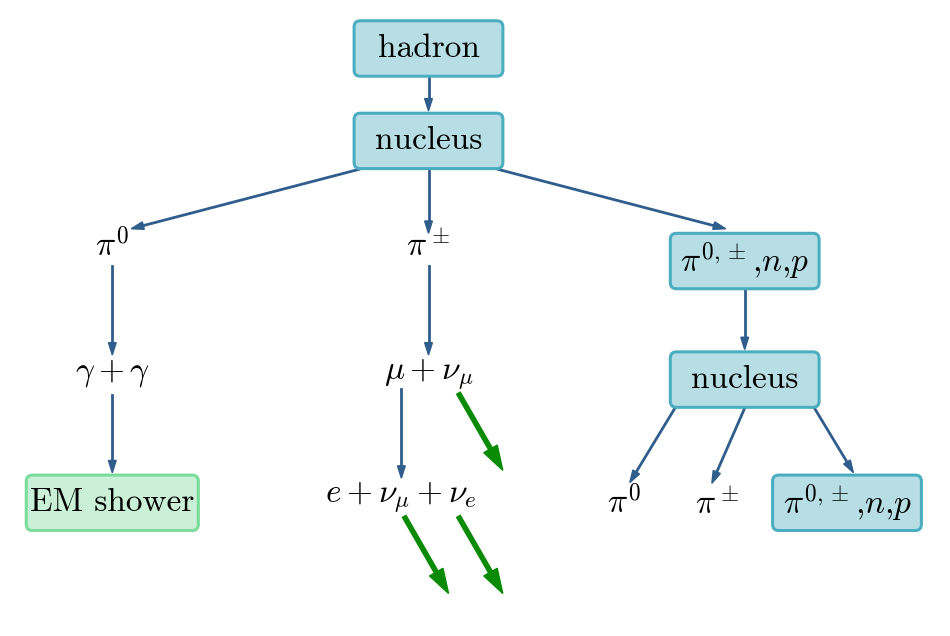

In [296]:
Theme.set("light")
#Theme.set("dark")


c_text = Theme.color()
c_edge = Theme.color()

if Theme.suff() == 'l':
    c1 = "#2F5D8C"     # CNO-I
    c2 =  "#0A8B05"     # CNO-II

    cb_1 = "#4BAEC0"
    cb_2 = "#7BDB9B"
else:
    c1 = "#5CC7CA"      # CNO-I
    c2 = "#40E648"      # CNO-II

    cb_1 = "#295B64"
    cb_2 = "#253F2E"


# ============================================================
# FIGURE
# ============================================================

W = 12
H = 8
    
fig, ax = plt.subplots(figsize=(W, H), frameon=False)


node_w = 1.8
node_h = 0.6


ax.set_xlim(0, W)
ax.set_ylim(0, H)

dW = W*0.05
ax.axis("off")
pos = {"hadron":(W/2 - dW,H-0.5),
       "nucleus1":(W/2 - dW,H-1.7),
       "nucleus2":(W*0.84 - dW,H*0.4),
       "pi0_1" : (W*0.16 - dW, H*0.6),
        "pipm_1" : (W/2 - dW, H*0.6),
        "hadrons":(W*0.84 - dW, H*0.6 - 0.06),
        "gamma":(W*0.16 - dW, H*0.4),
        "mu" : (W/2 - dW, H*0.4),
        "em": (W*0.16 - dW, H*0.2),
        "enu":(W/2 - dW, H*0.2),
        "hadrons2": (W*0.95 - dW, H*0.2),
        "pipm_2" : (W*0.81 - dW, H*0.2-0.14),
        "pi0_2" : (W*0.71 - dW, H*0.2-0.14),
        }

draw_node(
        "hadron",
        pos["hadron"],
        edgecolor=cb_1,
        facecolor=(cb_1, 0.4),
        node_w=node_w,
        node_h=node_h
    )

draw_node(
        "nucleus",
        pos["nucleus1"],
        edgecolor=cb_1,
        facecolor=(cb_1, 0.4),
        node_w=node_w,
        node_h=node_h
    )

arrow([
    point("hadron", "bottom") + (0, -0.07),
    point("nucleus1", "top") + (0, +0.25)
],
    color=c_cno1,
    lw=2,
)

ax.text(
    *pos["pi0_1"],
    r"$\pi^0$",
    fontsize=24,
    fontweight="bold",
    color=c_text,
    ha="center",
)
ax.text(
    *pos["pipm_1"],
    r"$\pi^\pm$",
    fontsize=24,
    fontweight="bold",
    color=c_text,
    ha="center",
)

draw_node(
        r"$\pi^{0,\pm}$,$n$,$p$",
        pos["hadrons"],
        edgecolor=cb_1,
        facecolor=(cb_1, 0.4),
        node_w=node_w,
        node_h=node_h
    )

arrow([ point("nucleus1", "bottom") + (-node_w/2, -0.07), point("pi0_1", "top") + (0.4, +0.1)],
    color=c1, lw=2)

arrow([ point("nucleus1", "bottom") + (0, -0.07), point("pipm_1", "top") + (0, +0.16)],
    color=c1, lw=2)

arrow([ point("nucleus1", "bottom") + (node_w/2, -0.07), point("hadrons", "top") + (-0.4, +0.16)],
    color=c1, lw=2)

ax.text(*pos["gamma"], r"$\gamma + \gamma$", 
        fontsize=24, fontweight="bold", color=c_text, ha="center",)
ax.text(*pos["mu"], r"$\mu + \nu_{\mu}$",
        fontsize=24, fontweight="bold", color=c_text, ha="center",)
draw_node("nucleus", pos["nucleus2"], edgecolor=cb_1, facecolor=(cb_1, 0.4),
        node_w=node_w, node_h=node_h)

arrow([ point("pi0_1", "center") + (0, -0.12), point("gamma", "top") + (0, +0.18)],
    color=c1, lw=2)

arrow([ point("pipm_1", "center") + (0, -0.12), point("mu", "top") + (0, +0.18)],
    color=c1, lw=2)

arrow([ point("hadrons", "bottom") + (0, -0.07), point("nucleus2", "top") + (0, +0.25)],
    color=c1, lw=2)


draw_node("EM shower",pos["em"],
        edgecolor=cb_2, facecolor=(cb_2, 0.4), node_w=node_w+0.3, node_h=node_h)

draw_node(r"$\pi^{0,\pm}$,$n$,$p$",pos["hadrons2"],
        edgecolor=cb_1, facecolor=(cb_1, 0.4), node_w=node_w, node_h=node_h)

ax.text(*pos["enu"] + np.array([-0.35,0]), r"$e + \nu_{\mu} + \nu_e$", 
        fontsize=24, fontweight="bold", color=c_text, ha="center",)

ax.text(*pos["pi0_2"], r"$\pi^0$", 
        fontsize=24, fontweight="bold", color=c_text, ha="center",)
ax.text(*pos["pipm_2"], r"$\pi^\pm$", 
        fontsize=24, fontweight="bold", color=c_text, ha="center",)


arrow([ point("gamma", "center") + (0, -0.2), point("em", "top") + (0, +0.25)],
    color=c1, lw=2)
arrow([ point("mu", "center") + (-0.35, -0.12), point("enu", "top") + (-0.35, +0.18)],
    color=c1, lw=2)

arrow([ point("mu", "center") + (+0.4, -0.20), point("mu", "center") + (+0.8, -0.9)],
    color=c2, lw=4, h = 0.2,l=0.32)

arrow([ point("enu", "center") + (+0.4, -0.20), point("enu", "center") + (+0.8, -0.9)],
    color=c2, lw=4, h = 0.2,l=0.32)
arrow([ point("enu", "center") + (-0.3, -0.20), point("enu", "center") + (+0.1, -0.9)],
    color=c2, lw=4, h = 0.2,l=0.32)


arrow([ point("nucleus2", "bottom") + (node_w/2, -0.07), point("hadrons2", "top") + (0, +0.23)],
    color=c1, lw=2)
arrow([ point("nucleus2", "bottom") + (-node_w/2, -0.07), point("pi0_2", "top") + (0.16, +0.24)],
    color=c1, lw=2)
arrow([ point("nucleus2", "bottom") + (0, -0.07), point("pipm_2", "top") + (0, +0.24)],
    color=c1, lw=2)
output = Path("../docs/Neutrino/images") / f"HadronShower-{Theme.suff()}.svg"
plt.savefig(output, transparent=True,bbox_inches="tight")
plt.show()

In [7]:

INPUT_FILE = "flues/FluxCos-d.svg"
OUTPUT_FILE = "flues/FluxCos-d_modified.svg"

In [4]:
import re
from xml.etree import ElementTree as ET

SVG_NS = "http://www.w3.org/2000/svg"
ET.register_namespace("", SVG_NS)
ET.register_namespace("inkscape", "http://www.inkscape.org/namespaces/inkscape")
ET.register_namespace("sodipodi", "http://sodipodi.sourceforge.net/DTD/sodipodi-0.dtd")
ET.register_namespace("xlink", "http://www.w3.org/1999/xlink")


# Бирюзовый цвет для границы
STROKE_COLOR = "#00CED1"   # darkturquoise / бирюзовый
STROKE_WIDTH = "1.11845"   # как у эталонов, можно не менять

CUSTOM_TAG = "data-small-rect"
CUSTOM_TAG_VALUE = "true"


def parse_path_d(d):
    """
    Разбирает d и возвращает список команд (команда, [аргументы]).
    Поддерживает M, m, H, h, V, v, L, l, Z, z.
    """
    tokens = re.findall(r"[MmLlHhVvZz]|-?\d+\.?\d*(?:[eE][-+]?\d+)?", d)
    commands = []
    i = 0
    while i < len(tokens):
        cmd = tokens[i]
        if cmd in "MmLlHhVvZz":
            args = []
            i += 1
            while i < len(tokens) and tokens[i] not in "MmLlHhVvZz":
                args.append(float(tokens[i]))
                i += 1
            commands.append((cmd, args))
        else:
            i += 1
    return commands


def get_bbox(d):
    """Приблизительный bounding box для путей, состоящих из M/H/V/L/Z."""
    cmds = parse_path_d(d)
    if not cmds:
        return None

    xs, ys = [], []
    cur_x, cur_y = 0.0, 0.0
    start_x, start_y = 0.0, 0.0

    for cmd, args in cmds:
        if cmd in ("M", "m"):
            for j in range(0, len(args), 2):
                x, y = args[j], args[j + 1]
                if cmd == "m":
                    x += cur_x
                    y += cur_y
                cur_x, cur_y = x, y
                if j == 0:
                    start_x, start_y = cur_x, cur_y
                xs.append(cur_x)
                ys.append(cur_y)
        elif cmd in ("L", "l"):
            for j in range(0, len(args), 2):
                x, y = args[j], args[j + 1]
                if cmd == "l":
                    x += cur_x
                    y += cur_y
                cur_x, cur_y = x, y
                xs.append(cur_x)
                ys.append(cur_y)
        elif cmd in ("H", "h"):
            for a in args:
                x = a + (cur_x if cmd == "h" else 0)
                cur_x = x
                xs.append(cur_x)
                ys.append(cur_y)
        elif cmd in ("V", "v"):
            for a in args:
                y = a + (cur_y if cmd == "v" else 0)
                cur_y = y
                xs.append(cur_x)
                ys.append(cur_y)
        elif cmd in ("Z", "z"):
            cur_x, cur_y = start_x, start_y
            xs.append(cur_x)
            ys.append(cur_y)

    if not xs or not ys:
        return None
    return min(xs), min(ys), max(xs), max(ys)


def is_target_rect(path_elem):
    """
    Определяет, является ли <path> маленьким горизонтальным прямоугольником,
    похожим на path46/path47.
    """
    d = path_elem.get("d", "")
    if not d:
        return False

    # Должен быть замкнутый прямоугольник: M ... H ... V ... H ... Z
    if not re.search(r"[Zz]", d):
        return False
    if not (re.search(r"[Hh]", d) and re.search(r"[Vv]", d)):
        return False

    # Только M/H/V/L/Z — никаких кривых
    if re.search(r"[CcSsQqTtAa]", d):
        return False

    bbox = get_bbox(d)
    if bbox is None:
        return False
    x0, y0, x1, y1 = bbox
    w = x1 - x0
    h = y1 - y0

    # Размеры: ширина 12..18, высота 1..4 (по эталонам path46/path47)
    # Можно немного расширить: 10..20 и 1..5
    if not (10 <= w <= 20):
        return False
    if not (1 <= h <= 5):
        return False

    # Проверка стиля: жирная обводка (не тонкая сетка)
    style = path_elem.get("style", "")
    m = re.search(r"stroke-width:\s*([\d.]+)", style)
    if m:
        sw = float(m.group(1))
        # У сетки stroke-width ~0.22, у гистограмм ~1.11
        if sw < 0.5:
            return False

    return True


def make_turquoise_border(path_elem):
    """Красит только границу (stroke) в бирюзовый, fill оставляет none."""
    style = path_elem.get("style", "")

    # Убираем старые stroke и stroke-opacity
    style = re.sub(r"stroke:[^;]*;?", "", style)
    style = re.sub(r"stroke-opacity:[^;]*;?", "", style)

    # Убеждаемся, что fill:none (только граница)
    if "fill:none" not in style:
        style = re.sub(r"fill:[^;]*;?", "", style)
        style += "fill:none;"

    # Добавляем бирюзовый stroke
    if style and not style.endswith(";"):
        style += ";"
    style += f"stroke:{STROKE_COLOR};stroke-opacity:1"

    path_elem.set("style", style)
    path_elem.set(CUSTOM_TAG, CUSTOM_TAG_VALUE)


def main():
    tree = ET.parse(INPUT_FILE)
    root = tree.getroot()

    count = 0
    for elem in root.iter(f"{{{SVG_NS}}}path"):
        if is_target_rect(elem):
            make_turquoise_border(elem)
            count += 1
            print(f"Обработан: id={elem.get('id', '?')}  d={elem.get('d', '')[:60]}")

    print(f"\nВсего обработано элементов: {count}")
    tree.write(OUTPUT_FILE, encoding="UTF-8", xml_declaration=True)
    print(f"Результат сохранён в {OUTPUT_FILE}")


if __name__ == "__main__":
    main()

Обработан: id=path46  d=M 66.629102,77.982529 H 81.169235 V 75.969502 H 66.629102 Z
Обработан: id=path47  d=M 81.169102,78.206529 H 95.485235 V 75.969555 H 81.169102 Z
Обработан: id=path48  d=M 95.485101,79.325195 H 109.80123 V 77.312169 H 95.485101 Z
Обработан: id=path49  d=m 109.8011,79.102529 h 14.5396 v -2.013027 h -14.5396 z
Обработан: id=path50  d=m 124.3411,80.667862 h 14.31613 V 78.654835 H 124.3411 Z
Обработан: id=path51  d=m 138.6571,80.443862 h 14.5396 v -2.013027 h -14.5396 z
Обработан: id=path52  d=m 153.1971,79.549195 h 14.31613 V 77.312222 H 153.1971 Z
Обработан: id=path53  d=m 167.5131,78.878529 h 14.54013 V 76.865502 H 167.5131 Z
Обработан: id=path155  d=M 66.629102,234.11852 H 81.169235 V 232.1055 H 66.629102 Z
Обработан: id=path156  d=m 81.169102,232.77586 h 14.316133 v -1.78959 H 81.169102 Z
Обработан: id=path157  d=m 95.485101,233.22386 h 14.316129 v -2.01303 H 95.485101 Z
Обработан: id=path158  d=m 109.8011,232.55319 h 14.5396 v -2.01355 h -14.5396 z
Обработан: id

In [10]:
import re
from xml.etree import ElementTree as ET

SVG_NS = "http://www.w3.org/2000/svg"
ET.register_namespace("", SVG_NS)
ET.register_namespace("inkscape", "http://www.inkscape.org/namespaces/inkscape")
ET.register_namespace("sodipodi", "http://sodipodi.sourceforge.net/DTD/sodipodi-0.dtd")
ET.register_namespace("xlink", "http://www.w3.org/1999/xlink")


STROKE_COLOR = "#00CED1"
CUSTOM_TAG = "data-small-rect"
CUSTOM_TAG_VALUE = "true"


def parse_path_d(d):
    tokens = re.findall(r"[MmLlHhVvZz]|-?\d+\.?\d*(?:[eE][-+]?\d+)?", d)
    commands = []
    i = 0
    while i < len(tokens):
        cmd = tokens[i]
        if cmd in "MmLlHhVvZz":
            args = []
            i += 1
            while i < len(tokens) and tokens[i] not in "MmLlHhVvZz":
                args.append(float(tokens[i]))
                i += 1
            commands.append((cmd, args))
        else:
            i += 1
    return commands


def get_bbox_raw(d):
    """Bounding box в координатах самого path (без transform)."""
    cmds = parse_path_d(d)
    if not cmds:
        return None
    xs, ys = [], []
    cur_x, cur_y = 0.0, 0.0
    start_x, start_y = 0.0, 0.0
    for cmd, args in cmds:
        if cmd in ("M", "m"):
            for j in range(0, len(args), 2):
                x, y = args[j], args[j + 1]
                if cmd == "m":
                    x += cur_x; y += cur_y
                cur_x, cur_y = x, y
                if j == 0:
                    start_x, start_y = cur_x, cur_y
                xs.append(cur_x); ys.append(cur_y)
        elif cmd in ("L", "l"):
            for j in range(0, len(args), 2):
                x, y = args[j], args[j + 1]
                if cmd == "l":
                    x += cur_x; y += cur_y
                cur_x, cur_y = x, y
                xs.append(cur_x); ys.append(cur_y)
        elif cmd in ("H", "h"):
            for a in args:
                x = a + (cur_x if cmd == "h" else 0)
                cur_x = x
                xs.append(cur_x); ys.append(cur_y)
        elif cmd in ("V", "v"):
            for a in args:
                y = a + (cur_y if cmd == "v" else 0)
                cur_y = y
                xs.append(cur_x); ys.append(cur_y)
        elif cmd in ("Z", "z"):
            cur_x, cur_y = start_x, start_y
            xs.append(cur_x); ys.append(cur_y)
    if not xs or not ys:
        return None
    return min(xs), min(ys), max(xs), max(ys)


def parse_transform(transform_str):
    """
    Возвращает матрицу 2x3 (a,b,c,d,e,f) для простых transform-выражений.
    Поддерживает matrix(...), translate(...), scale(...).
    Возвращает None, если не удалось разобрать.
    """
    if not transform_str:
        return None
    transform_str = transform_str.strip()
    m = re.match(r"matrix\(([^)]+)\)", transform_str)
    if m:
        vals = [float(v) for v in re.split(r"[,\s]+", m.group(1).strip())]
        if len(vals) == 6:
            return tuple(vals)
    m = re.match(r"translate\(([^)]+)\)", transform_str)
    if m:
        vals = [float(v) for v in re.split(r"[,\s]+", m.group(1).strip())]
        tx = vals[0] if len(vals) > 0 else 0
        ty = vals[1] if len(vals) > 1 else 0
        return (1, 0, 0, 1, tx, ty)
    m = re.match(r"scale\(([^)]+)\)", transform_str)
    if m:
        vals = [float(v) for v in re.split(r"[,\s]+", m.group(1).strip())]
        sx = vals[0] if len(vals) > 0 else 1
        sy = vals[1] if len(vals) > 1 else sx
        return (sx, 0, 0, sy, 0, 0)
    return None


def apply_matrix_to_bbox(bbox, matrix):
    """
    Применяет матрицу (a,b,c,d,e,f) к bbox (x0,y0,x1,y1).
    Возвращает новый bbox в координатах пользователя.
    """
    x0, y0, x1, y1 = bbox
    a, b, c, d, e, f = matrix
    corners = [(x0, y0), (x1, y0), (x0, y1), (x1, y1)]
    new_xs, new_ys = [], []
    for x, y in corners:
        nx = a * x + c * y + e
        ny = b * x + d * y + f
        new_xs.append(nx); new_ys.append(ny)
    return min(new_xs), min(new_ys), max(new_xs), max(new_ys)


def is_target_rect(path_elem):
    d = path_elem.get("d", "")
    if not d:
        return False
    if not re.search(r"[Zz]", d):
        return False
    if not (re.search(r"[Hh]", d) and re.search(r"[Vv]", d)):
        return False
    if re.search(r"[CcSsQqTtAa]", d):
        return False

    bbox = get_bbox_raw(d)
    if bbox is None:
        return False

    # Применяем transform, если есть
    transform_str = path_elem.get("transform", "")
    if transform_str:
        matrix = parse_transform(transform_str)
        if matrix is not None:
            bbox = apply_matrix_to_bbox(bbox, matrix)

    x0, y0, x1, y1 = bbox
    w = x1 - x0
    h = y1 - y0

    # Обе оси: делаем нормализацию, если h > w (транспонированный прямоугольник)
    short_side = min(w, h)
    long_side = max(w, h)

    # Ориентируемся на эталоны: длинная сторона ~14, короткая ~2
    # После transform короткая сторона может быть любой из двух
    if not (8 <= long_side <= 25):
        return False
    if not (1 <= short_side <= 6):
        return False

    return True


def make_turquoise_border(path_elem):
    style = path_elem.get("style", "")
    style = re.sub(r"stroke:[^;]*;?", "", style)
    style = re.sub(r"stroke-opacity:[^;]*;?", "", style)
    if "fill:none" not in style:
        style = re.sub(r"fill:[^;]*;?", "", style)
        style += "fill:none;"
    if style and not style.endswith(";"):
        style += ";"
    style += f"stroke:{STROKE_COLOR};stroke-opacity:1"
    path_elem.set("style", style)
    path_elem.set(CUSTOM_TAG, CUSTOM_TAG_VALUE)


def main():
    tree = ET.parse(INPUT_FILE)
    root = tree.getroot()

    count = 0
    for elem in root.iter(f"{{{SVG_NS}}}path"):
        if is_target_rect(elem):
            make_turquoise_border(elem)
            count += 1
            print(f"Обработан: id={elem.get('id', '?')}")

    print(f"\nВсего обработано элементов: {count}")
    tree.write(OUTPUT_FILE, encoding="UTF-8", xml_declaration=True)
    print(f"Результат сохранён в {OUTPUT_FILE}")


if __name__ == "__main__":
    main()

Обработан: id=path44
Обработан: id=path46
Обработан: id=path47
Обработан: id=path48
Обработан: id=path49
Обработан: id=path50
Обработан: id=path51
Обработан: id=path52
Обработан: id=path53
Обработан: id=path54
Обработан: id=path153
Обработан: id=path155
Обработан: id=path156
Обработан: id=path157
Обработан: id=path158
Обработан: id=path159
Обработан: id=path160
Обработан: id=path161
Обработан: id=path162
Обработан: id=path163
Обработан: id=path266
Обработан: id=path268
Обработан: id=path269
Обработан: id=path270
Обработан: id=path271
Обработан: id=path272
Обработан: id=path273
Обработан: id=path274
Обработан: id=path275
Обработан: id=path276
Обработан: id=path371
Обработан: id=path373
Обработан: id=path374
Обработан: id=path375
Обработан: id=path376
Обработан: id=path377
Обработан: id=path378
Обработан: id=path379
Обработан: id=path380
Обработан: id=path381
Обработан: id=path478
Обработан: id=path480
Обработан: id=path481
Обработан: id=path482
Обработан: id=path483
Обработан: id=path48